# Actividad sumativa 2

## Parte 1

* Se le proporcionó un dataset ficticio que modela distintas variables en una potencial ciudad multicultural y multietnica.

  * Identifique el problema que el dataset busca resolver

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('datos_puntaje_social.csv')
df.head()

,ID,Idioma,Barrio,Ingresos_Mensuales,Minutos_App_Dia,Score
0,1001,Inglés,Periferia,5.005.942.851.264.260,52,6.217.805.281.560.590
1,1002,Árabe,Zonas Rurales,5.290.942.572.590.740,45,5.684.399.468.287.600
2,1003,Bengalí,Suburbios,1.610.427.533.236.400,29,6.054.030.928.167.240
3,1004,Español,Zonas Rurales,13.546.012.530.431.000,34,6.077.903.220.708.420
4,1005,Inglés,Zonas Rurales,402.257.043.200.964,53,5.890.108.778.920.370


El contexto del dataset representa a un grupo de usuarios de una ciudad, datos sobre ellos, y el puntaje social final que tienen. Su proposito probablemente sea crear un sistema de perfiles para la poblacion, basandose en el tiempo de uso de una app y en el contexto social de cada persona. Considero que el problema de fondo que intenta representar es como las columnas no se relacionan con el puntaje de cada persona, quiza por un sistema de analisis opaco fuera de los datos, y tambien la exclusion de lenguas indigenas del analisis, al no solo ser solo menor en cantidad de ID's al resto, sino que tambien tienen la mayoria de sus ingresos removidos del analisis. (Esto concluido del analisis inferior)

  ---
  * Identifique variables faltantes en el dataset para poder hacerlo de manera adecuada

In [3]:
# Revisemos las columnas que tenemos:
print(list(df.columns))

['ID', 'Idioma', 'Barrio', 'Ingresos_Mensuales', 'Minutos_App_Dia', 'Score']


Si el sistema de puntaje social resulta de todas estas variables, sería útil tener los valores de la edad de la persona, su nivel de educación, años de vida en la ciudad y ocupación laboral. Para asi tener mas informacion de la persona y poder relacionar el valor de su puntaje final con su calidad de vida.

---
* ¿Puede el problema presentado solucionarse solo mediante el uso de tecnología? justifíque su respuesta (Hint: ¿Qué es el tecnosolucionismo?).

No, el tecnosolucionismo habla de que con solo tener más tecnologia se va a solucionar el problema, pero por la diferencia de datos debido a las barreras linguisticas esta claro de que no es asi, y que se necesita una recopilacion de datos mucho mas equitativa si se quiere conseguir un analisis que verdaderamente represente la realidad.

---  
  * Haga graficos comparando las variables idioma, barrio, ingresos y uso_tech con puntaje

In [4]:
df_graf = df.copy()
# Llenamos de 0 los datos nulos para los graficos
df_graf['Ingresos_Mensuales'] = df_graf['Ingresos_Mensuales'].fillna('0')
# Transformamos los datos de str a int
df_graf['Ingresos_Mensuales'] = df_graf['Ingresos_Mensuales'].str.replace('.', '').astype(int)
df_graf['Score'] = df_graf['Score'].str.replace('.', '').astype(int)

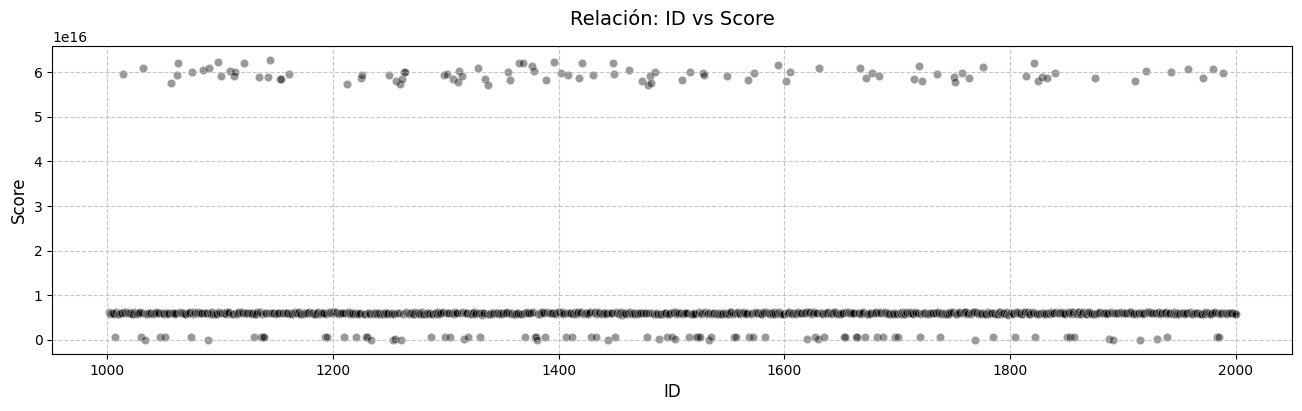

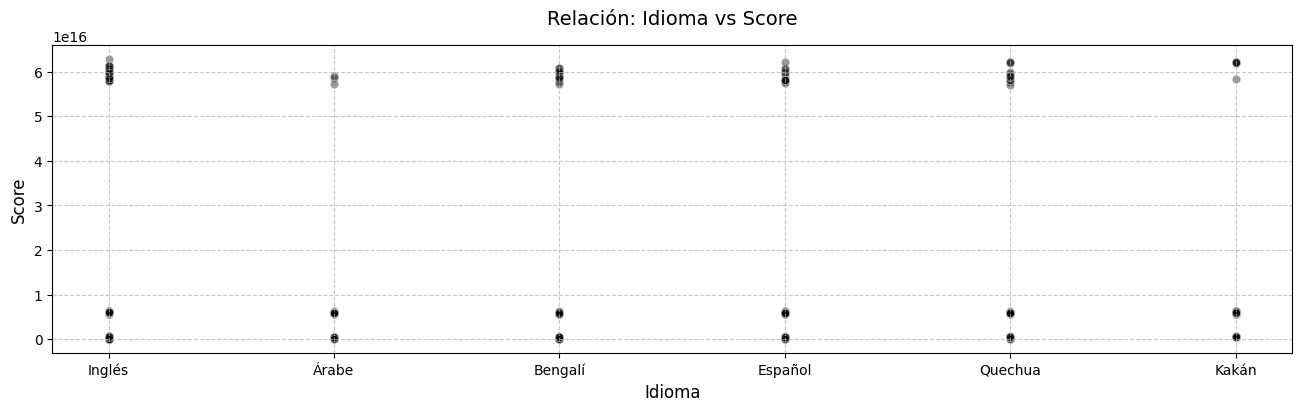

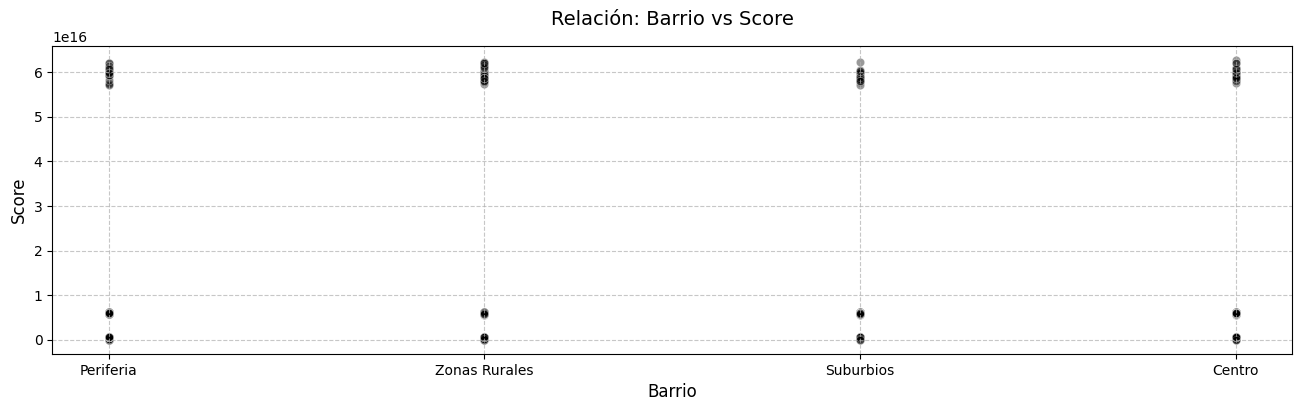

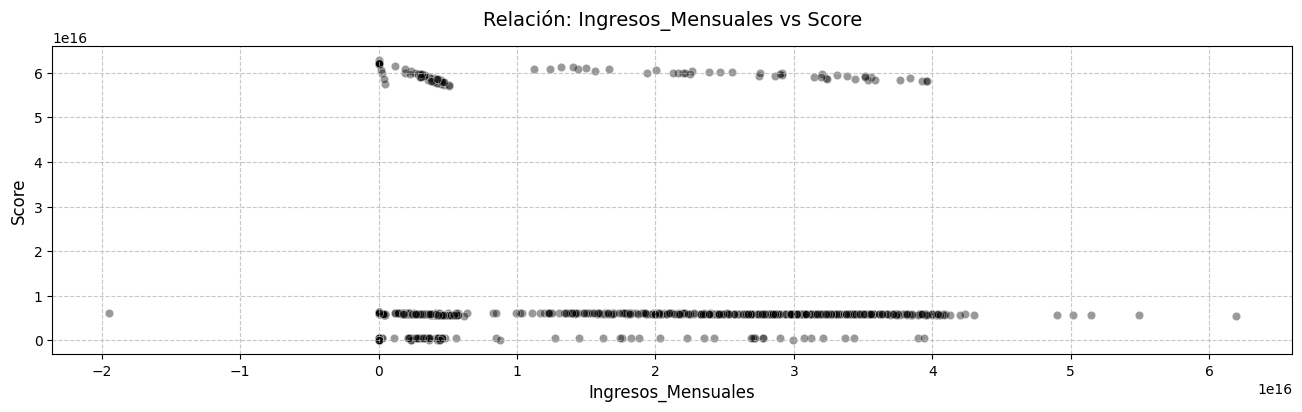

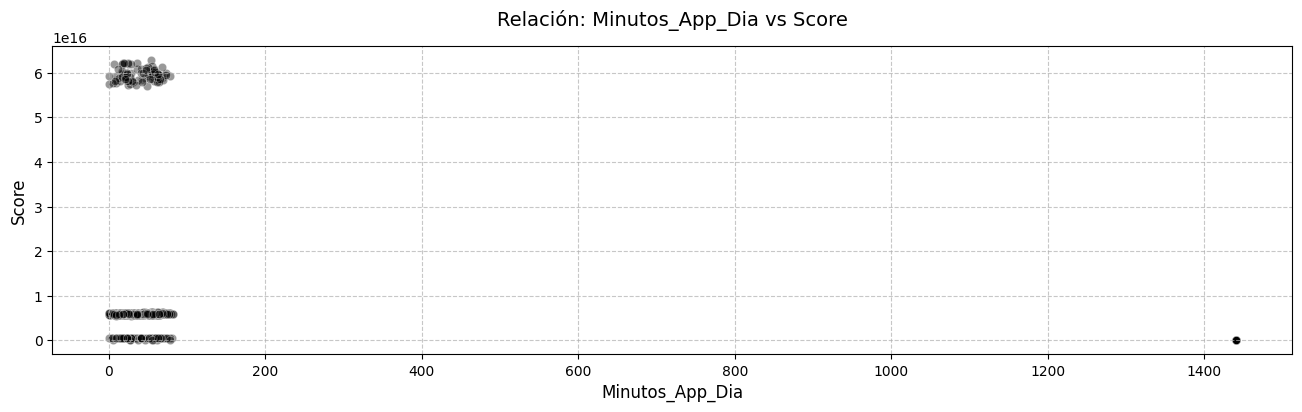

In [5]:
# Por cada columna hacemos una grafico por medio de un scatterplot de esta contra Score
for columna in list(df_graf.columns[:5]):
    plt.figure(figsize=(16, 4))
    plt.scatter(df_graf[columna], df_graf['Score'],
        alpha=0.4,
        c='black',
        edgecolor='white',
        linewidth=0.5)
    plt.title(f'Relación: {columna} vs Score', fontsize=14, pad=15)
    plt.xlabel(columna, fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

  ---
  * Haga graficos comparando las variables, idioma, barrio y uso_tech con ingresos

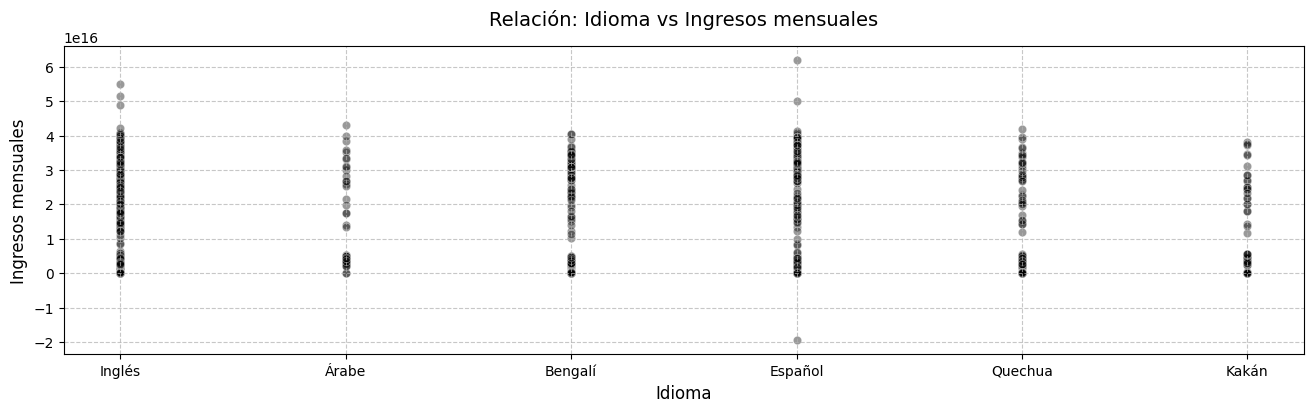

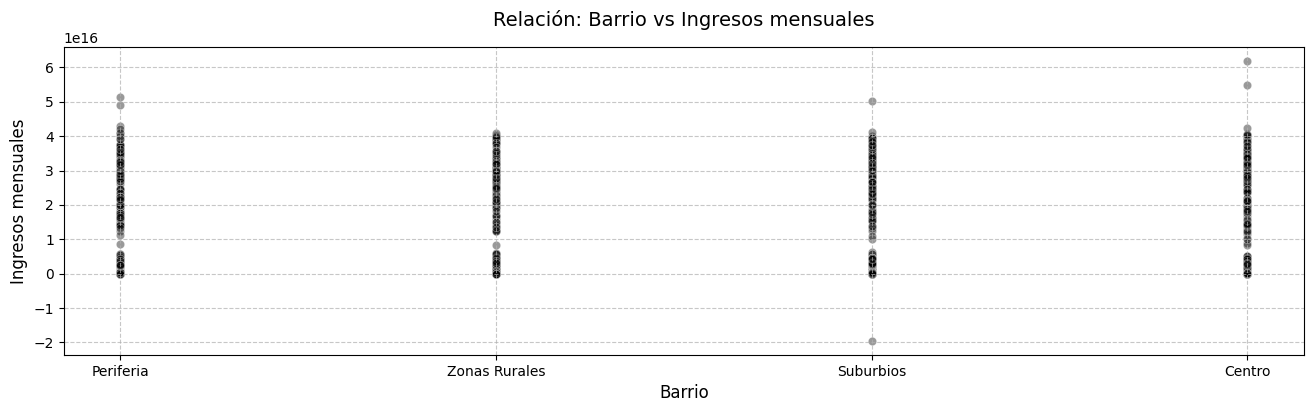

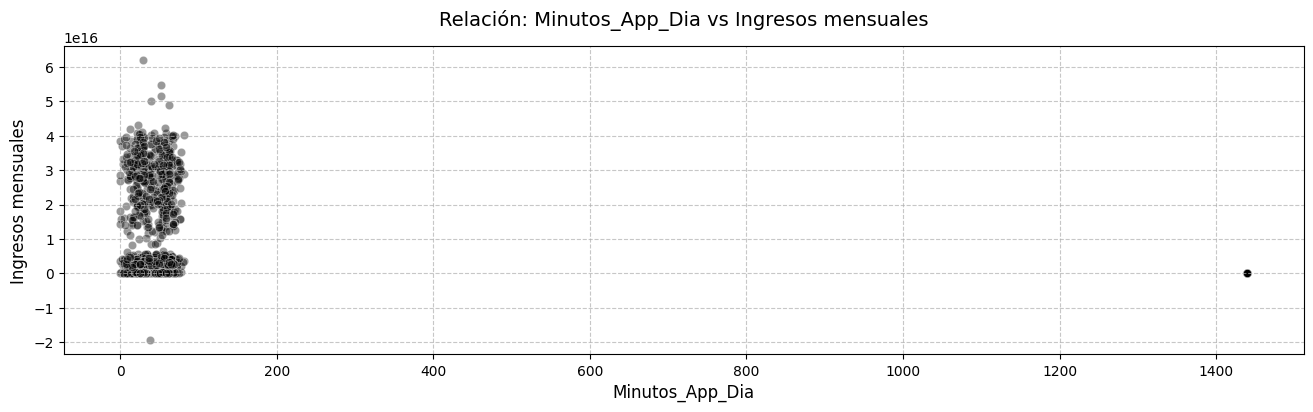

In [6]:
columnas = ['Idioma', 'Barrio', 'Minutos_App_Dia']
for columna in columnas:
    plt.figure(figsize=(16, 4))
    plt.scatter(df_graf[columna], df_graf['Ingresos_Mensuales'],
        alpha=0.4,
        c='black',
        edgecolor='white',
        linewidth=0.5)
    plt.title(f'Relación: {columna} vs Ingresos mensuales', fontsize=14, pad=15)
    plt.xlabel(columna, fontsize=12)
    plt.ylabel('Ingresos mensuales', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

  ---
  * Identifique datos atípicos en el dataset
  

In [7]:
# Veamos mas informacion sobre estos outliers
df_graf.nlargest(n=11, columns='Minutos_App_Dia', keep='all')

,ID,Idioma,Barrio,Ingresos_Mensuales,Minutos_App_Dia,Score
32,1033,Inglés,Periferia,999990,1440,99990
233,1234,Español,Periferia,999990,1440,99990
252,1253,Quechua,Periferia,999990,1440,99990
259,1260,Inglés,Periferia,999990,1440,99990
380,1381,Inglés,Suburbios,999990,1440,99990
443,1444,Inglés,Zonas Rurales,999990,1440,99990
532,1533,Árabe,Zonas Rurales,999990,1440,99990
768,1769,Inglés,Centro,999990,1440,99990
890,1891,Bengalí,Suburbios,999990,1440,99990
914,1915,Español,Centro,999990,1440,99990


En la columna de minutos diarios en que se usan la app hay outliers fáciles de notar, con ingresos, uso tech y score iguales, con un valor de uso de app de 1440. En ingresos mensuales hay un outlier con un valor negativo. En el puntaje social y en el ingreso mensual podemos ver que la diferencia entre valores es demasiado alta, con varias ID teniendo un puntaje o ingresos muchísimo más altos que el promedio. 

  ---
  * ¿Cuales son posibles explicaciones para estos datos atípicos? (Hint: ¿Qué es el tecnofacismo?)

Considero que la mejor explicacion seria que el dataset no solo fue creado con multiples errores, sino que tambien fue modificado por alguien por motivos propios, lo mas probable es que para que se pueda hacer creer la mentira de que las personas pasan mucho mas tiempo en la app. Al elevar los valores las medidas estadisticas de cuanto tiempo pasa la gente en la app cambiarian completamente.

  ---
  * Maneje los datos atipicos, de manera que el dataset pueda ser mejor utilizado para cumplir su labor

Al eliminar los outliers el dataset se vuelve mucho mas manejable, y aunque la diferencia de puntajes sigue siendo enorme, no se pueden eliminar ninguna de las dos zonas superior o inferior ya que afectaria a la distribucion original de los datos. Lo cual tendria consecuencias en futuros analisis

In [8]:
# Quitemos las filas, de cualquier forma no parece que sus valores sean realmente correctos.
df_graf = df_graf[(df_graf['Ingresos_Mensuales'] >= 0)]
df_graf = df_graf[(df_graf['Minutos_App_Dia'] < 1440)]

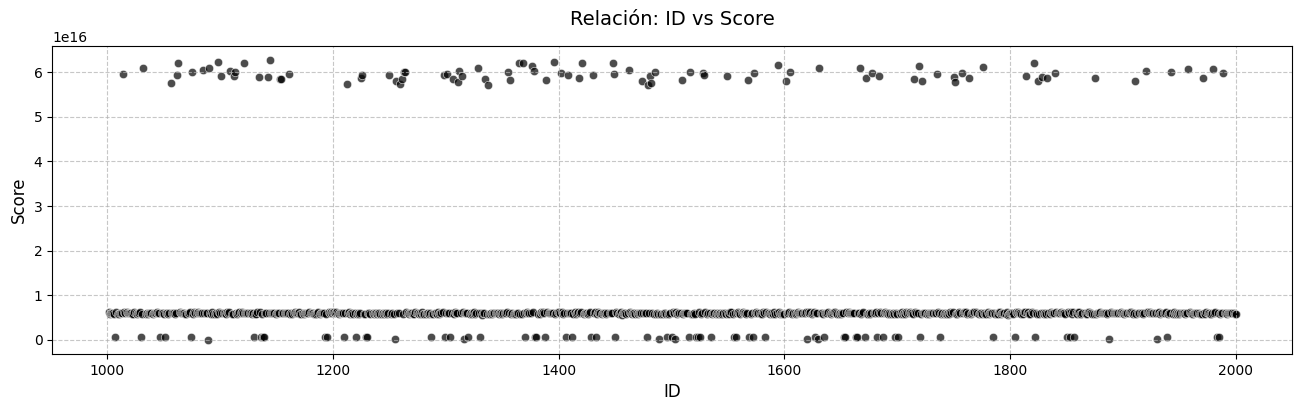

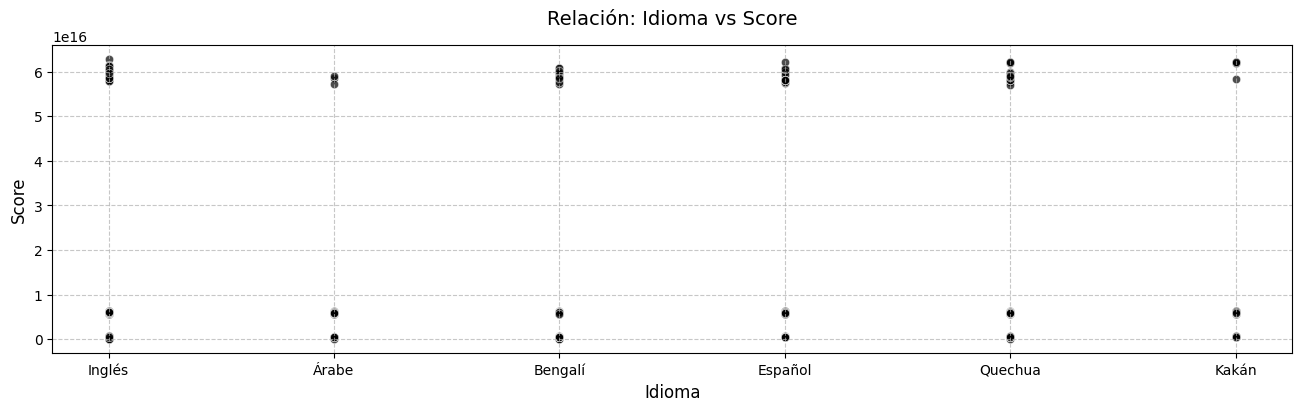

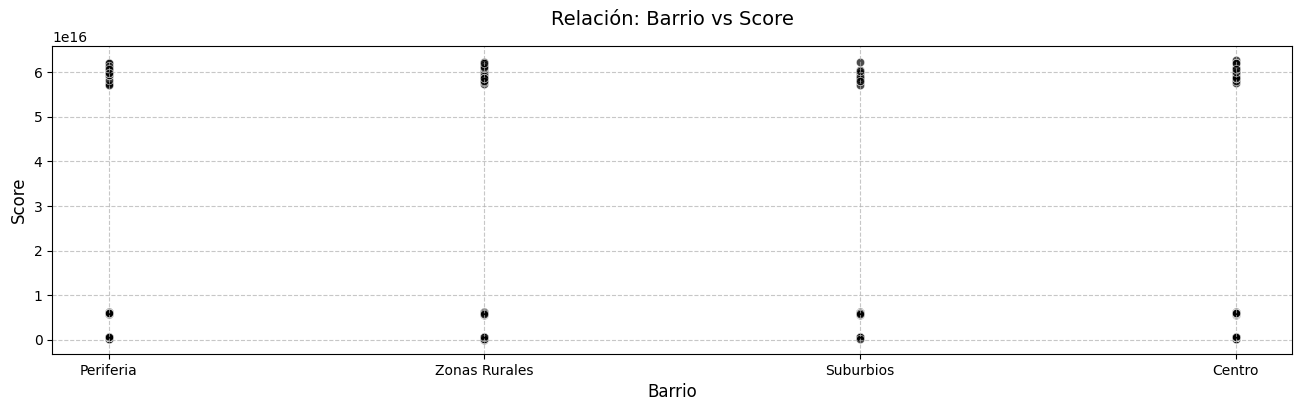

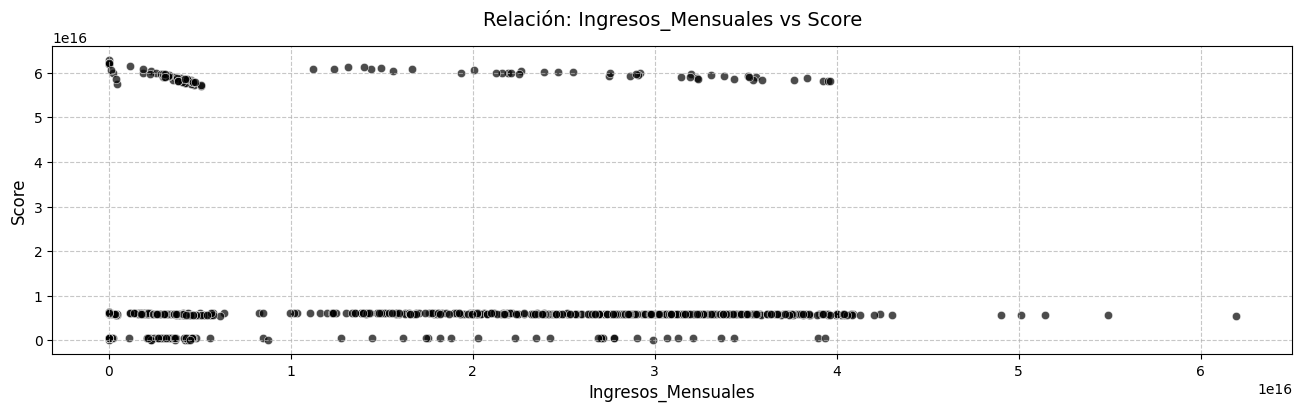

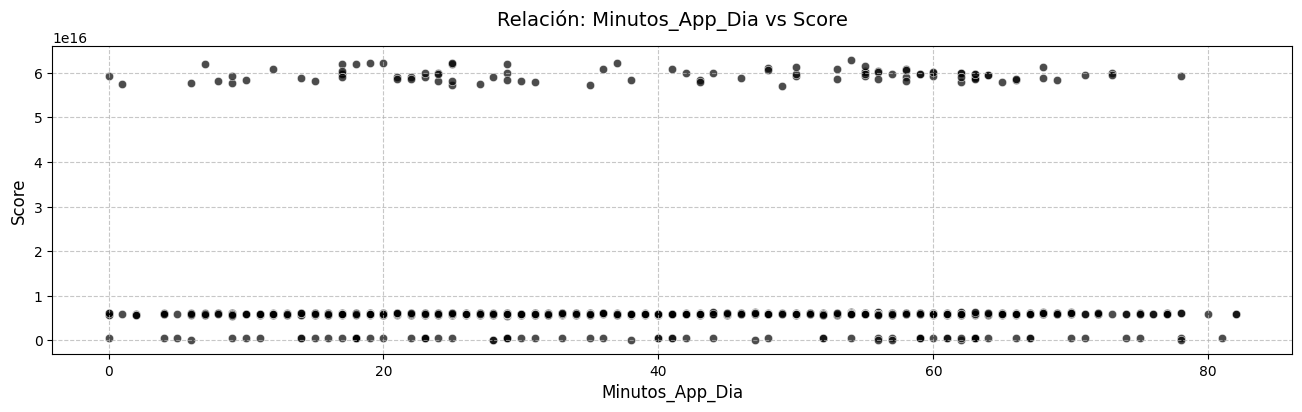

In [9]:
# Por cada columna volvamos a hacer un scatterplot
for columna in list(df_graf.columns[:5]):
    plt.figure(figsize=(16, 4))
    plt.scatter(df_graf[columna], df_graf['Score'],
        alpha=0.7,
        c='black',
        edgecolor='white',
        linewidth=0.5)
    plt.title(f'Relación: {columna} vs Score', fontsize=14, pad=15)
    plt.xlabel(columna, fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

  ---
  * Identifique datos nulos en el dataset

In [10]:
df.info()
print(f'Tenemos {df['Ingresos_Mensuales'].isna().sum()} valores nulos.')

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  1000 non-null   int64
 1   Idioma              1000 non-null   str  
 2   Barrio              1000 non-null   str  
 3   Ingresos_Mensuales  884 non-null    str  
 4   Minutos_App_Dia     1000 non-null   int64
 5   Score               1000 non-null   str  
dtypes: int64(2), str(4)
memory usage: 47.0 KB
Tenemos 116 valores nulos.


  ---
  * ¿Cuales son posibles explicaciones para estos datos nulos? (Hint: ¿Qué es el tecnochovinismo?)  

In [11]:
print(df_graf.value_counts('Idioma'))
df6 = df_graf[df_graf['Ingresos_Mensuales'] == 0]
df6.value_counts('Idioma')

Idioma
Inglés     416
Español    189
Bengalí    143
Quechua    106
Kakán       90
Árabe       45
Name: count, dtype: int64


Idioma
Kakán      42
Quechua    35
Inglés     22
Español    10
Bengalí     6
Árabe       1
Name: count, dtype: int64

Los datos nulos se presentan sobre todo en IDs de personas que hablan lenguajes indígenas, esto es probablemente porque no se están recopilando bien los datos en aquellas zonas debido a las barreras lingüísticas. Lo cual muestra una posible despreciación por la cultura y forma de vida de las personas indigenas, al intentar inculcar un modelo de puntaje social aun cuando los datos no están siendo bien recopilados y no muestran la verdadera realidad de la poblacion.

---
* Maneje los datos nulos, de manera que el dataset pueda ser mejor utilizado para cumplir su labor

In [12]:
# Reemplazemos todos los valores nulos por la media.

def cambiar_nulos_por_media(idioma):
    media = idioma['Ingresos_Mensuales'].mean()
    idioma['Ingresos_Mensuales'] = idioma['Ingresos_Mensuales'].replace(0, media)
    return idioma

df_no_nulos = df_graf.groupby('Idioma').apply(cambiar_nulos_por_media)
df_no_nulos.info()

<class 'pandas.DataFrame'>
MultiIndex: 989 entries, ('Bengalí', np.int64(2)) to ('Árabe', np.int64(998))
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  989 non-null    int64
 1   Barrio              989 non-null    str  
 2   Ingresos_Mensuales  989 non-null    int64
 3   Minutos_App_Dia     989 non-null    int64
 4   Score               989 non-null    int64
dtypes: int64(4), str(1)
memory usage: 49.4+ KB


De esta forma tenemos un dataframe final en el que no se presentan outliers, y al menos se intenta incluir a la poblacion de lengua indigena al utilizar la media de sus ingresos para representar los datos faltantes. Lo cual es mucho mejor que dejarlos como 0 ya que si se dejan como 0 se representaria a esas lenguas como si no tuvieran ingresos. (Y esto tambien para los nulos de otros lenguajes)

---
  * Identifique que otro uso se le podría dar al dataset

Seria interesante para poder analisar las diferencias de calidad de vida para personas de lenguas indigenas y en la periferia en comparacion con personas que viven en el centro, con el fin asi de mejorar su acceso a servicios basicos. Ademas, se podria mapear las zonas donde hay mas participantes, para saber cuales territorios si desean participar del analisis, y cuales preferirian rechazar el avance moderno que podria ser innecesario.

Pero para eso es necesario recopilar mejor los datos en una forma mucho más manejable, y trabajar respecto a las altas diferencias entre ID's para valores como los ingresos y los puntajes. Ya que actualmente las columnas del dataset no parecen tener relacion con los puntajes de cada persona.

## Parte 2 (opcional)

* Lea atentamente los articulos proporcionados y responda con 2 argumentos claros y concisos contra las tesis principales de cada artículo.
  * https://archive.ph/BCy6M
  * https://archive.ph/x4qlK

* Si bien es opcional, el cumplimiento adecuado de esta parte contará con decimas para su nota FINAL de taller. (0.2)